# AI Recommendation System Using MovieLens 100k

This notebook demonstrates a complete recommender-systems workflow using the MovieLens 100k dataset. The goal is to build, evaluate, and improve a collaborative filtering model that generates personalized movie recommendations.

## Objectives
- Understand the fundamentals of recommendation systems
- Explore and preprocess the MovieLens 100k dataset
- Split the dataset into training and testing sets
- Train a Singular Value Decomposition (SVD) recommendation model
- Evaluate model performance using RMSE
- Tune key hyperparameters
- Generate top-N movie recommendations
- Consider fairness, privacy, and transparency in recommender systems

# Understanding Recommendation Systems

#### Collaborative filtering

Collaborative filtering uses user-item interaction data, such as ratings, to recommend products or content. It identifies patterns among users with similar preferences and predicts what a user is likely to enjoy.

- **User-based vs. item-based:**
  - *User-based:* Recommend items to a user based on the preferences of similar users. If users A and B have rated many items similarly, items liked by B but not yet seen by A may be recommended.
  - *Item-based:* Recommend items similar to those the user has already liked. Similarity is computed from how users rate items together.

#### Collaborative vs. content-based filtering

- **Collaborative filtering:** Learns from the collective behavior of users. It assumes that users who agreed in the past will continue to agree in the future.
- **Content-based filtering:** Uses item attributes such as genre, tags, or metadata, along with a user's preferences, to recommend similar items. This method is especially useful when rich item descriptions are available.

# Install Libraries

In [1]:
!pip install surprise

In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# Data exploration and preprocessing

This project uses the MovieLens 100k dataset, which contains ratings assigned by users to movies. The dataset includes user IDs, movie IDs, ratings, and timestamps, making it well-suited for collaborative filtering recommender systems.

In [5]:
from surprise import Dataset, SVD, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

# Load data and split
data = Dataset.load_builtin("ml-100k",prompt=False)

In [6]:
# Load the MovieLens data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Convert the Surprise Dataset to a pandas DataFrame
ratings = pd.DataFrame(data.raw_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])

# Display the first few rows
print(ratings.head())


  user_id item_id  rating  timestamp
0     196     242     3.0  881250949
1     186     302     3.0  891717742
2      22     377     1.0  878887116
3     244      51     2.0  880606923
4     166     346     1.0  886397596


In [8]:
# Display the number of ratings, unique users, unique movies, and the range of ratings
print('Number of Ratings:', len(ratings))
print('Number of unique users:', ratings['user_id'].nunique())
print('Number of unique movies:', ratings['item_id'].nunique())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())

# Display the first few rows of the ratings DataFrame
print(ratings.head())

Number of Ratings: 100000
Number of unique users: 943
Number of unique movies: 1682
Rating range: 1.0 to 5.0
  user_id item_id  rating  timestamp
0     196     242     3.0  881250949
1     186     302     3.0  891717742
2      22     377     1.0  878887116
3     244      51     2.0  880606923
4     166     346     1.0  886397596


In [9]:
# Display the structure and summary of the ratings DataFrame
print(ratings.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100000 non-null  str    
 1   item_id    100000 non-null  str    
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.1 MB
None


There are no missing values, so no null-data cleaning is required. The rating column is currently stored as an integer and should be converted to float for analysis and modeling.

In [10]:
# Convert rating column to float type
ratings['rating'] = ratings['rating'].astype(float)

In [11]:
# check for duplicate rows based on user_id and item_id
duplicate_rows = ratings.duplicated(subset=['user_id', 'item_id'])

In [12]:
print('Number of duplicate rows based on user_id and item_id:', duplicate_rows.sum())

Number of duplicate rows based on user_id and item_id: 0


In [13]:
# Display the summary statistics of the ratings DataFrame
print(ratings.describe())

              rating
count  100000.000000
mean        3.529860
std         1.125674
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000


#### Visualize data to gain insights into the distribution of ratings, number of ratings per user, etc.

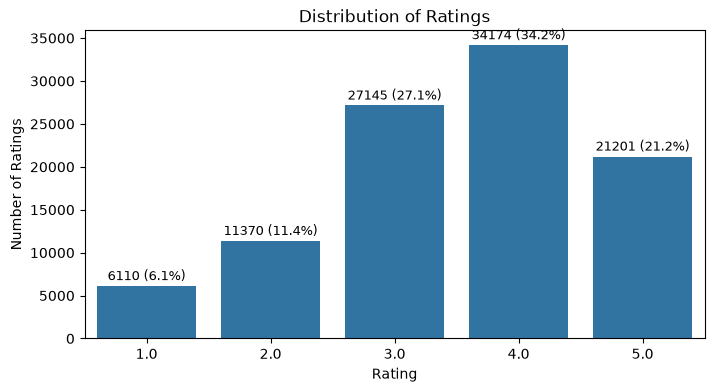

In [25]:
# Display the distribution of ratings using a bar plot
rating_counts = ratings.groupby('rating').size()

total = rating_counts.sum()
percentages = (rating_counts / total) * 100

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values)

for i, (count, pct) in enumerate(zip(rating_counts.values, percentages.values)):
    ax.text(
        i,
        count + max(rating_counts.values) * 0.01,
        f"{count} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

Most ratings are 3 or higher, which suggests a generally positive rating pattern in the dataset. Only a small percentage of ratings are at the lowest end, indicating that users tend to rate movies more favorably than negatively.

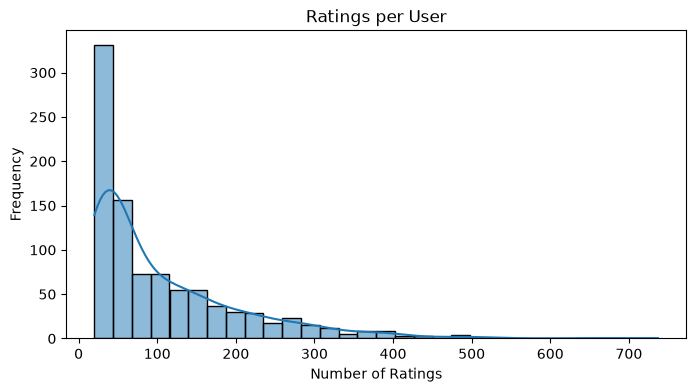

In [15]:
# Display the distribution of ratings per user using a histogram
user_counts = ratings.groupby('user_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=30, kde=True)
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

Most users rated fewer than 100 movies, which reflects a sparse interaction pattern that is common in recommender system datasets.

# Data Splitting

The dataset is split into training and test sets. The training data is used to learn the underlying patterns in user-item preferences, while the test set is used to evaluate how well the model generalizes to unseen ratings.

In [16]:
ratings_final = ratings.rename(columns={"rating": "raw_ratings"})
print(ratings_final)

      user_id item_id  raw_ratings  timestamp
0         196     242          3.0  881250949
1         186     302          3.0  891717742
2          22     377          1.0  878887116
3         244      51          2.0  880606923
4         166     346          1.0  886397596
...       ...     ...          ...        ...
99995     880     476          3.0  880175444
99996     716     204          5.0  879795543
99997     276    1090          1.0  874795795
99998      13     225          2.0  882399156
99999      12     203          3.0  879959583

[100000 rows x 4 columns]


In [17]:
# Split Data for training and testing
trainset, testset = train_test_split(data, test_size=0.25)
allData, noData = train_test_split(data, test_size=1)


# Model Selection

SVD (Singular Value Decomposition) is a widely used matrix factorization method for collaborative filtering. It decomposes the user-item rating matrix into latent factors that capture hidden preferences and behavior patterns.

In [18]:
# Using the Surprise library, for model implementations SVD algorithms.
from surprise import SVD

model = SVD()
model.fit(trainset)

# Model Evaluation

In [19]:
from surprise.model_selection import cross_validate

# Run 5-fold cross-validation and print results.
cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9316  0.9314  0.9403  0.9404  0.9388  0.9365  0.0041  
MAE (testset)     0.7360  0.7352  0.7408  0.7423  0.7393  0.7387  0.0027  
Fit time          0.75    0.80    0.70    0.78    0.64    0.73    0.06    
Test time         0.15    0.09    0.24    0.08    0.36    0.19    0.10    


{'test_rmse': array([0.93160791, 0.93138759, 0.94031564, 0.94041216, 0.93876915]),
 'test_mae': array([0.73601509, 0.73515285, 0.74083537, 0.74226009, 0.73930869]),
 'fit_time': (0.7453048229217529,
  0.799048662185669,
  0.6977694034576416,
  0.7772250175476074,
  0.6364090442657471),
 'test_time': (0.1515810489654541,
  0.09468650817871094,
  0.2410893440246582,
  0.08144831657409668,
  0.3569052219390869)}

In [20]:
# Make Predictions
predictions = model.test(testset)

In [21]:
# After making predictions, calculate RMSE
from surprise import accuracy

rmse = accuracy.rmse(predictions)
print(f"Root Mean Squared Error: {rmse}")

RMSE: 0.7421
Root Mean Squared Error: 0.7420635337588102


#  Hyperparameter Tuning

Hyperparameters such as n_factors, n_epochs, and lr_all can be tuned to improve the model's predictive performance. A careful search over these values helps balance accuracy, convergence speed, and generalization.

In [22]:
from surprise.model_selection import GridSearchCV

param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
grid_search.fit(data)
print(grid_search.best_params)

{'rmse': {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005}}


# Top N Recommendations

The model is trained, so we can generate top-10 recommendations for each user by sorting the predicted ratings and selecting the highest-scoring unseen items.

In [23]:
def get_top_n(predictions, n):

   top_n = {}
   for uid, iid, true_r, est, _ in predictions:
       if uid not in top_n:
           top_n[uid] = []
       top_n[uid].append((iid, est))


   for uid, user_ratings in top_n.items():
       user_ratings.sort(key=lambda x: x[1], reverse=True)
       top_n[uid] = user_ratings[:n]

   return top_n

recommendations = get_top_n(predictions, n=10)

for uid, user_ratings in recommendations.items():
   print(uid, [iid for (iid, _) in user_ratings])

922 ['427', '151', '1', '919', '153', '382', '418', '15', '257', '230']
279 ['474', '152', '96', '65', '1500', '1', '10', '514', '919', '433']
455 ['22', '200', '79', '515', '126', '196', '298', '269', '135', '42']
398 ['498', '480', '124', '185', '520', '735', '71', '474', '205', '283']
458 ['285', '187', '654', '530', '179', '526', '517', '137', '180', '1039']
770 ['246', '275', '151', '129', '25', '1', '297', '508', '924', '288']
314 ['378', '742', '28', '423', '588', '15', '405', '125', '73', '845']
693 ['357', '134', '97', '604', '144', '521', '506', '199', '9', '196']
608 ['1039', '317', '288', '603', '735', '483', '213', '427', '83', '499']
2 ['306', '269', '276', '1', '282', '277', '13', '292', '315', '279']
246 ['50', '178', '741', '616', '68', '236', '55', '746', '196', '470']
787 ['258', '361', '329', '345', '904', '359', '748', '1433', '348', '259']
23 ['408', '134', '603', '59', '170', '56', '173', '432', '224', '694']
268 ['408', '483', '246', '180', '203', '12', '357', '

# Ethical considerations

This project highlights the importance of fairness, privacy, and transparency in recommender systems. Bias in the training data can lead to unfair or less diverse recommendations, while privacy must be respected when handling user behavior and preference data. The system should also be transparent about how recommendations are generated and why certain items are suggested.

In summary, this notebook demonstrates how to build, evaluate, and improve a collaborative filtering recommendation system using the MovieLens 100k dataset.